In [2]:
import numpy as np
import matplotlib.pyplot as plt
import csv
# 让画的图显示在当前 notebook 里
%matplotlib inline
plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置黑体（支持中文）
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题

In [3]:
#读取 top250.csv，放进 numpy 里
filename = "Top250.csv"
names = []
D1_list = []
D2_list = []
countries = []
types_list = []
scores = []
nums = []
years= []

with open(filename, "r", encoding="utf-8-sig") as f:
    reader = csv.DictReader(f)
    for row in reader:
        names.append(row["name"])
        D1_list.append(row["D1"])
        D2_list.append(row["D2"])
        countries.append(row["country"])
        types_list.append(row["types"])
        scores.append(float(row["score"]))
        num_str = row["num"].replace(",", "")
        nums.append(int(num_str))
        years.append(int(row["year"]))

# 转成 numpy 数组
names = np.array(names)
D1_arr = np.array(D1_list)
D2_arr = np.array(D2_list)
countries = np.array(countries)
types_arr = np.array(types_list)
scores = np.array(scores)
nums = np.array(nums)

print("读入电影数量：", len(names))

读入电影数量： 249


各国家影片数量：
美国: 111
日本: 34
英国: 20
中国香港: 19
中国大陆: 18
韩国: 11
法国: 6
意大利: 6
中国台湾: 6
澳大利亚: 3
德国: 3
印度: 2
西班牙: 2
新西兰: 1
巴西: 1
爱尔兰: 1
瑞典: 1
伊朗: 1
丹麦: 1
阿根廷: 1
黎巴嫩: 1


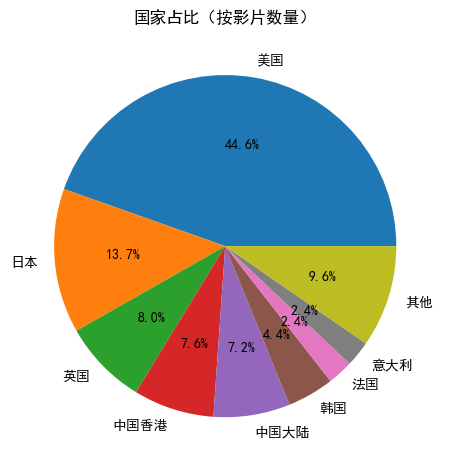

In [4]:
# 国家统计占比
unique_countries, country_counts = np.unique(countries, return_counts=True)
idx_sort_country = np.argsort(-country_counts)
unique_countries = unique_countries[idx_sort_country]
country_counts = country_counts[idx_sort_country]

print("各国家影片数量：")
for c, cnt in zip(unique_countries, country_counts):
    print(f"{c}: {cnt}")

# 只画前 8 个国家，剩下合并成“其他”
top_k = 8
top_countries = unique_countries[:top_k]
top_counts = country_counts[:top_k]

if len(unique_countries) > top_k:
    other_count = country_counts[top_k:].sum()
    top_countries = np.append(top_countries, "其他")
    top_counts = np.append(top_counts, other_count)

plt.figure()
plt.pie(top_counts, labels=top_countries, autopct="%1.1f%%")
plt.title("国家占比（按影片数量）")
plt.tight_layout()
plt.show()

各类型影片数量：
剧情: 167
喜剧: 23
动作: 17
动画: 14
奇幻: 6
犯罪: 6
科幻: 5
悬疑: 3
传记: 2
冒险: 2
爱情: 2
儿童: 1
纪录片: 1


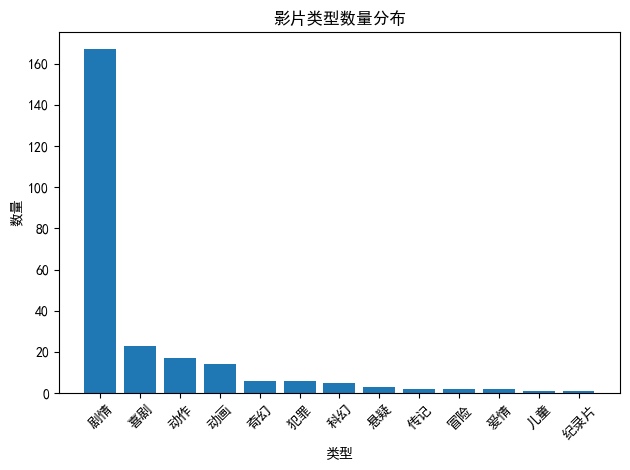

In [5]:
#影片类型占比（柱状图）
unique_types, type_counts = np.unique(types_arr, return_counts=True)
idx_sort_type = np.argsort(-type_counts)
unique_types = unique_types[idx_sort_type]
type_counts = type_counts[idx_sort_type]

print("各类型影片数量：")
for t, cnt in zip(unique_types, type_counts):
    print(f"{t}: {cnt}")

plt.figure()
plt.bar(unique_types, type_counts)
plt.title("影片类型数量分布")
plt.xlabel("类型")
plt.ylabel("数量")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

按点评数量排序（Top 10）：
1. 肖申克的救赎 - 3235723 人评价-9.7 评价
2. 这个杀手不太冷 - 2522041 人评价-9.4 评价
3. 千与千寻 - 2498589 人评价-9.4 评价
4. 泰坦尼克号 - 2458306 人评价-9.5 评价
5. 阿甘正传 - 2397636 人评价-9.5 评价
6. 霸王别姬 - 2388121 人评价-9.6 评价
7. 我不是药神 - 2323133 人评价-9.0 评价
8. 盗梦空间 - 2292458 人评价-9.4 评价
9. 疯狂动物城 - 2257728 人评价-9.3 评价
10. 星际穿越 - 2138435 人评价-9.4 评价


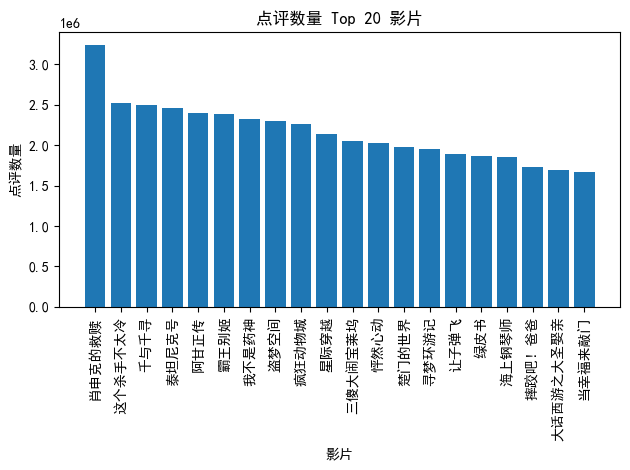

In [6]:
#按评论人数排序，看看 Top 10 + 画 Top 20
idx_sort_num = np.argsort(-nums)
names_sorted_by_num = names[idx_sort_num]
nums_sorted = nums[idx_sort_num]
scores_sorted = scores[idx_sort_num]

print("按点评数量排序（Top 10）：")
for i in range(10):
    print(f"{i+1}. {names_sorted_by_num[i]} - {nums_sorted[i]} 人评价-{scores_sorted[i]} 评价")

# 前 20 画柱状图
top_n = 20
plt.figure()
plt.bar(range(top_n), nums_sorted[:top_n])
plt.xticks(range(top_n), names_sorted_by_num[:top_n], rotation=90)
plt.xlabel("影片")
plt.ylabel("点评数量")
plt.title("点评数量 Top 20 影片")
plt.tight_layout()
plt.show()

导演上榜数量排序（前 15）：
1. 宫崎骏 - 8 部
2. 史蒂文·斯皮尔伯格 - 6 部
3. 克里斯托弗·诺兰 - 6 部
4. 李安 - 5 部
5. 彼特·道格特 - 4 部
6. 是枝裕和 - 4 部
7. 今敏 - 4 部
8. 王家卫 - 4 部
9. 大卫·芬奇 - 4 部
10. 姜文 - 3 部
11. 弗朗西斯·福特·科波拉 - 3 部
12. 彼得·杰克逊 - 3 部
13. 刘镇伟 - 3 部
14. 拉娜·沃卓斯基 - 3 部
15. 昆汀·塔伦蒂诺 - 3 部


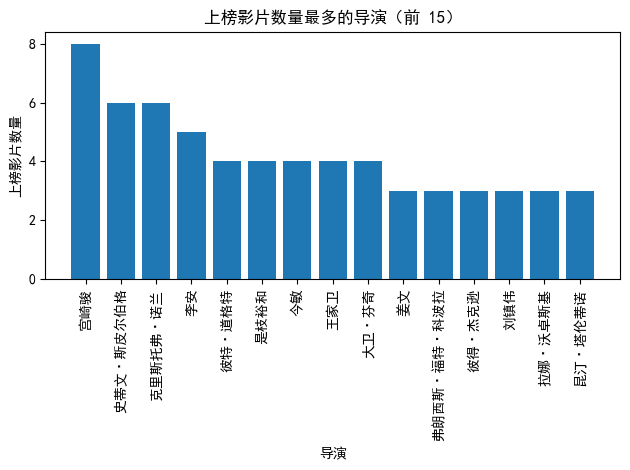

In [7]:
#导演上榜数量排序
all_directors = []

for d1, d2 in zip(D1_list, D2_list):
    if d1.strip():
        all_directors.append(d1.strip())
    if d2.strip():
        all_directors.append(d2.strip())

all_directors = np.array(all_directors)

unique_directors, director_counts = np.unique(all_directors, return_counts=True)
idx_sort_director = np.argsort(-director_counts)
unique_directors = unique_directors[idx_sort_director]
director_counts = director_counts[idx_sort_director]

print("导演上榜数量排序（前 15）：")
for i in range(min(15, len(unique_directors))):
    print(f"{i+1}. {unique_directors[i]} - {director_counts[i]} 部")

top_d = 15
plt.figure()
plt.bar(range(top_d), director_counts[:top_d])
plt.xticks(range(top_d), unique_directors[:top_d], rotation=90)
plt.xlabel("导演")
plt.ylabel("上榜影片数量")
plt.title("上榜影片数量最多的导演（前 15）")
plt.tight_layout()
plt.show()

平均评分最高的导演 Top 5：
1. 陈凯歌 - 平均分：9.60
2. 比利·怀尔德 - 平均分：9.60
3. 谢添 - 平均分：9.60
4. 罗伯特·泽米吉斯 - 平均分：9.50
5. 罗伯托·贝尼尼 - 平均分：9.50
6. 黄建新 - 平均分：9.50
7. 杨亚洲 - 平均分：9.50
8. 吕克·贝松 - 平均分：9.40
9. 莱塞·霍尔斯道姆 - 平均分：9.40
10. 西德尼·吕美特 - 平均分：9.40


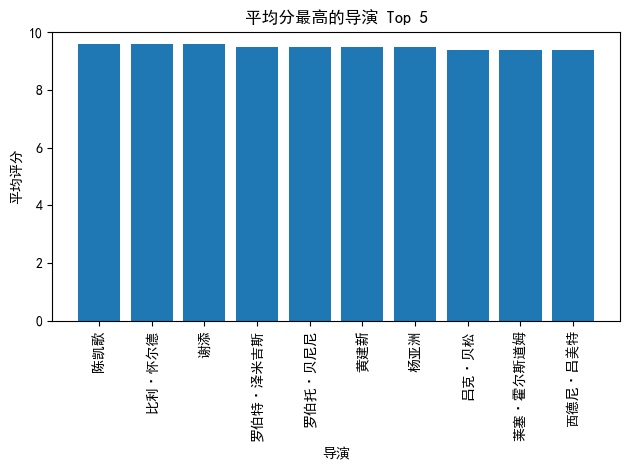

In [8]:
# 统计：导演 -> 参与影片的所有评分
director_scores = {}

for d1, d2, sc in zip(D1_list, D2_list, scores):
    for d in (d1.strip(), d2.strip()):
        if not d:   # 空字符串就跳过
            continue
        director_scores.setdefault(d, []).append(sc)

# 计算每个导演的平均分
director_avg = {d: np.mean(score_list) for d, score_list in director_scores.items()}

# 按平均分从高到低排序
sorted_directors = sorted(director_avg.items(), key=lambda x: x[1], reverse=True)

# 取前 10 名
top10 = sorted_directors[:10]

print("平均评分最高的导演 Top 5：")
for i, (d, avg_sc) in enumerate(top10, start=1):
    print(f"{i}. {d} - 平均分：{avg_sc:.2f}")

top5_director_names  = [d for d, _ in top10]
top5_director_scores = [s for _, s in top10]

plt.figure()
plt.bar(top5_director_names, top5_director_scores)
plt.ylim(0, 10)  # 评分一般 0~10
plt.ylabel("平均评分")
plt.xlabel("导演")
plt.title("平均分最高的导演 Top 5")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [9]:
multi_director_idx = []

for i, (d1, d2) in enumerate(zip(D1_list, D2_list)):
    # 若 D1 和 D2 都不是空字符串 → 至少两个导演
    if d1.strip() and d2.strip():
        multi_director_idx.append(i)

print("拥有两位以上导演的电影数量：", len(multi_director_idx))

# 这些电影的评分与评价人数
multi_scores = scores[multi_director_idx]
multi_votes = nums[multi_director_idx]

print("这些电影的平均评分：", np.mean(multi_scores).round(2))
print("这些电影的总评价人数：", np.sum(multi_votes))

# -------- 排名情况（按评分从高到低） --------
sorted_idx = np.argsort(-scores)  # 全部电影的评分从高到低的排序下标

# 计算这些电影在总榜单中的排名（1 为最高）
ranks = []

for idx in multi_director_idx:
    rank = np.where(sorted_idx == idx)[0][0] + 1
    ranks.append(rank)

print("\n排名情况（1 为最高）：")
print("最高排名：", min(ranks))
print("最低排名：", max(ranks))
print("平均排名：", round(np.mean(ranks), 2))

# 展示评分最高的前 5 部多导演电影
top5_idx = np.argsort(-multi_scores)[:5]
print("\n评分最高的多导演电影 Top 5：")
for j in top5_idx:
    real_idx = multi_director_idx[j]
    print(f"- {names[real_idx]} | 评分：{scores[real_idx]} | 评价人数：{nums[real_idx]}")


拥有两位以上导演的电影数量： 31
这些电影的平均评分： 8.92
这些电影的总评价人数： 26937943

排名情况（1 为最高）：
最高排名： 8
最低排名： 243
平均排名： 135.87

评分最高的多导演电影 Top 5：
- 背靠背，脸对脸 | 评分：9.5 | 评价人数：175676
- 疯狂动物城 | 评分：9.3 | 评价人数：2257728
- 无间道 | 评分：9.3 | 评价人数：1539795
- 触不可及 | 评分：9.3 | 评价人数：1274380
- 乱世佳人 | 评分：9.3 | 评价人数：780956


In [10]:
# ------ 1. 筛选 2010 年以后影片 ------
idx_after_2010 = [i for i, y in enumerate(years) if int(y) >= 2010]
idx_before_2010 = [i for i, y in enumerate(years) if int(y) < 2010]

count_after = len(idx_after_2010)
count_total = len(names)

print("2010 年以后上榜影片数量：", count_after)
print("占比：", round(count_after / count_total * 100, 2), "%")

# ------ 2. 国家占比 ------
country_count = {}

for i in idx_after_2010:
    c = countries[i]
    country_count[c] = country_count.get(c, 0) + 1

# 排序（按数量从高到低）
country_sorted = sorted(country_count.items(), key=lambda x: x[1], reverse=True)

print("\n2010 年后影片国家分布（从高到低）：")
for c, v in country_sorted:
    print(f"{c}: {v} 部，占比 {round(v/count_after*100, 2)}%")

# ------ 3. Top 5 导演（按参与数量） ------
director_count = {}

for i in idx_after_2010:
    for d in (D1_list[i], D2_list[i]):
        if d.strip():
            director_count[d] = director_count.get(d, 0) + 1

director_sorted = sorted(director_count.items(), key=lambda x: x[1], reverse=True)
top5_directors = director_sorted[:5]

print("\n2010 年后导演参与影片数量 Top 5：")
for d, n in top5_directors:
    print(f"{d}: {n} 部")

# ------ 4. 2010 年后影片评分 Top 10 ------
scores_after = scores[idx_after_2010]
sorted_after_indices = np.argsort(-scores_after)  # 从高到低

print("\n2010 年后评分最高 Top 10 影片：")
for rank in range(10):
    i_local = sorted_after_indices[rank]       # 在 after_2010 的局部 index
    i_real = idx_after_2010[i_local]           # 映射回真实 index
    print(f"{rank+1}. {names[i_real]} - 评分 {scores[i_real]}, 点评人数 {nums[i_real]}")

# ------ 5. 平均评分与平均点评人数对比 ------
avg_score_after = np.mean(scores[idx_after_2010])
avg_score_before = np.mean(scores[idx_before_2010])

avg_votes_after = np.mean(nums[idx_after_2010])
avg_votes_before = np.mean(nums[idx_before_2010])

print("\n评分与评价人数对比：")
print(f"2010 年以后平均评分：{avg_score_after:.2f}")
print(f"2010 年以前平均评分：{avg_score_before:.2f}")

print(f"2010 年以后平均点评人数：{avg_votes_after:.0f}")
print(f"2010 年以前平均点评人数：{avg_votes_before:.0f}")

2010 年以后上榜影片数量： 83
占比： 33.33 %

2010 年后影片国家分布（从高到低）：
美国: 37 部，占比 44.58%
韩国: 10 部，占比 12.05%
日本: 10 部，占比 12.05%
英国: 6 部，占比 7.23%
中国大陆: 4 部，占比 4.82%
西班牙: 2 部，占比 2.41%
意大利: 2 部，占比 2.41%
澳大利亚: 2 部，占比 2.41%
法国: 1 部，占比 1.2%
德国: 1 部，占比 1.2%
印度: 1 部，占比 1.2%
黎巴嫩: 1 部，占比 1.2%
丹麦: 1 部，占比 1.2%
瑞典: 1 部，占比 1.2%
中国香港: 1 部，占比 1.2%
阿根廷: 1 部，占比 1.2%
中国台湾: 1 部，占比 1.2%
爱尔兰: 1 部，占比 1.2%

2010 年后导演参与影片数量 Top 5：
克里斯托弗·诺兰: 3 部
李·昂克里奇: 2 部
大卫·叶茨: 2 部
彼特·道格特: 2 部
克里斯·桑德斯: 2 部

2010 年后评分最高 Top 10 影片：
1. 星际穿越 - 评分 9.4, 点评人数 2138435
2. 盗梦空间 - 评分 9.4, 点评人数 2292458
3. 疯狂动物城 - 评分 9.3, 点评人数 2257728
4. 熔炉 - 评分 9.3, 点评人数 1023937
5. 触不可及 - 评分 9.3, 点评人数 1274380
6. 还有明天 - 评分 9.3, 点评人数 341791
7. 海蒂和爷爷 - 评分 9.3, 点评人数 760036
8. 素媛 - 评分 9.3, 点评人数 766011
9. 天书奇谭 - 评分 9.2, 点评人数 328093
10. 辩护人 - 评分 9.2, 点评人数 651131

评分与评价人数对比：
2010 年以后平均评分：8.84
2010 年以前平均评分：9.00
2010 年以后平均点评人数：921663
2010 年以前平均点评人数：812508


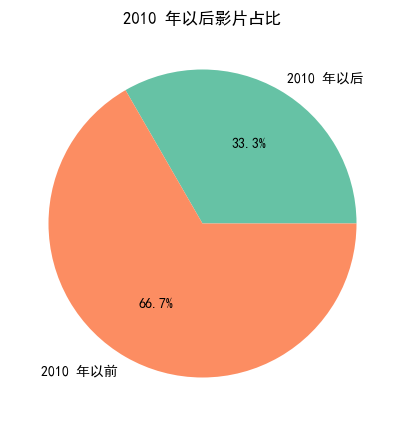

In [11]:
plt.figure(figsize=(5,5))
plt.pie(
    [count_after, count_total - count_after],
    labels=["2010 年以后", "2010 年以前"],
    autopct="%1.1f%%",
    colors=["#66c2a5", "#fc8d62"]
)
plt.title("2010 年以后影片占比")
plt.show()

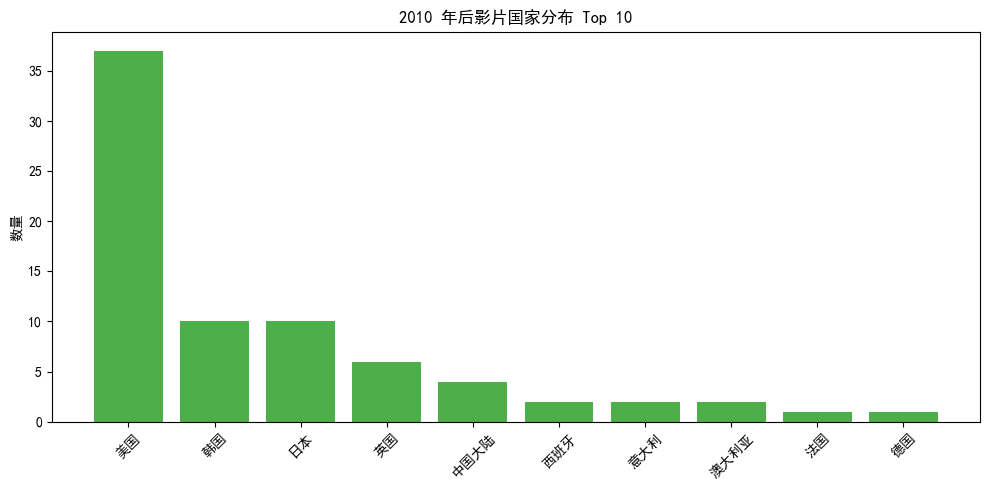

In [12]:
# 统计国家数量
country_count = {}
for i in idx_after_2010:
    c = countries[i]
    country_count[c] = country_count.get(c, 0) + 1

# 排序
country_sorted = sorted(country_count.items(), key=lambda x: x[1], reverse=True)

# 取 Top 10
top_countries = country_sorted[:10]
labels = [x[0] for x in top_countries]
values = [x[1] for x in top_countries]

# 柱状图
plt.figure(figsize=(10,5))
plt.bar(labels, values, color="#4daf4a")
plt.title("2010 年后影片国家分布 Top 10")
plt.ylabel("数量")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
import pandas as pd

scores_after = scores[idx_after_2010]
sorted_after_idx = np.argsort(-scores_after)

top10 = []
for rank in range(10):
    i_local = sorted_after_idx[rank]
    i_real = idx_after_2010[i_local]
    top10.append({
        "排名": rank + 1,
        "电影名称": names[i_real],
        "评分": scores[i_real],
        "评价人数": nums[i_real],
        "国家": countries[i_real],
        "导演1": D1_list[i_real],
        "导演2": D2_list[i_real]
    })
df_top10 = pd.DataFrame(top10)
df_top10

,排名,电影名称,评分,评价人数,国家,导演1,导演2
0,1,星际穿越,9.4,2138435,美国,克里斯托弗·诺兰,
1,2,盗梦空间,9.4,2292458,美国,克里斯托弗·诺兰,
2,3,疯狂动物城,9.3,2257728,美国,拜伦·霍华德,瑞奇·摩尔
3,4,熔炉,9.3,1023937,韩国,黄东赫,
4,5,触不可及,9.3,1274380,法国,奥利维·那卡什,艾力克·托兰达
5,6,还有明天,9.3,341791,意大利,宝拉·柯特莱西,
6,7,海蒂和爷爷,9.3,760036,德国,阿兰·葛斯彭纳,
7,8,素媛,9.3,766011,韩国,李濬益,
8,9,天书奇谭,9.2,328093,中国大陆,王树忱,钱运达
9,10,辩护人,9.2,651131,韩国,杨宇硕,


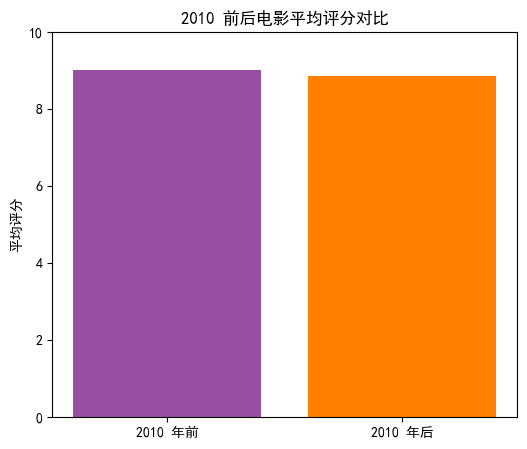

2010 年以前平均评分： 9.000000000000002
2010 年以后平均评分： 8.843373493975902


In [14]:
avg_score_after = np.mean(scores[idx_after_2010])
avg_score_before = np.mean(scores[idx_before_2010])

plt.figure(figsize=(6,5))
plt.bar(["2010 年前", "2010 年后"], [avg_score_before, avg_score_after],
        color=["#984ea3", "#ff7f00"])
plt.ylabel("平均评分")
plt.title("2010 前后电影平均评分对比")
plt.ylim(0,10)
plt.show()

print("2010 年以前平均评分：", avg_score_before)
print("2010 年以后平均评分：", avg_score_after)

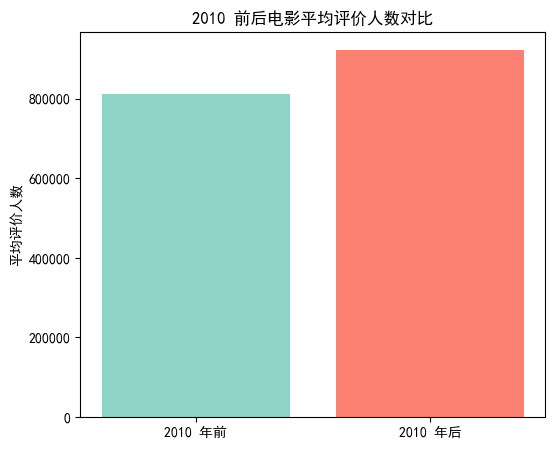

2010 年以前平均评价人数： 812508.1144578314
2010 年以后平均评价人数： 921663.2891566266


In [15]:
avg_votes_after = np.mean(nums[idx_after_2010])
avg_votes_before = np.mean(nums[idx_before_2010])

plt.figure(figsize=(6,5))
plt.bar(["2010 年前", "2010 年后"], [avg_votes_before, avg_votes_after],
        color=["#8dd3c7", "#fb8072"])
plt.ylabel("平均评价人数")
plt.title("2010 前后电影平均评价人数对比")
plt.show()

print("2010 年以前平均评价人数：", avg_votes_before)
print("2010 年以后平均评价人数：", avg_votes_after)